<a href="https://colab.research.google.com/github/liliannakakaawa/iris-streamlit-app-lilian/blob/main/Python_C2_08_Dimensionality_Reduction_with_Deep_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Welcome Back to Python Course 2!**

In the previous lesson, we covered how to perform Data visualization using tSNE and UMAP. We also learned the syntax for writing functions. If you haven't completed these topics, please refer to L07 Data visualization using tSNE and UMAP before practicing the codes for this lesson.

# **Let's Recap!**

Now that we've covered essential concepts in [L08 - Dimensionality Reduction with Deep Learning](https://learn.omicslogic.com/Python/python-course-2-introduction-to-data-science-bioml/lesson/08-dimensionality-reduction-with-deep-learning), let's take a moment to reinforce what we've learned so far. We'll start with a brief recap of the codes and techniques we've explored in the lesson.

# **Lesson Code Breakdown**

Dimensionality Reduction with Deep Learning

## **1. Load Packages**

In [ ]:
import pandas as pd
import sys
import csv
from sklearn.model_selection import train_test_split
from keras.layers import Dense,Input,Dropout
from keras.models import Model
from matplotlib import pyplot as plt
from sklearn.neural_network import MLPClassifier as ANN


The code snippet imports various libraries and modules for neural networks and data handling, including pandas for data manipulation, scikit-learn for splitting data, Keras for defining network layers and models, and matplotlib for visualization. It also imports the MLPClassifier class from scikit-learn for implementing artificial neural networks.

## **2. Load Data**

In [ ]:
train = pd.read_csv("https://raw.githubusercontent.com/pine-bio-support/Predictive_model_Classification_Regression/main/train_data.txt", sep='\t')
test = pd.read_csv("https://raw.githubusercontent.com/pine-bio-support/Predictive_model_Classification_Regression/main/test_data.txt", sep='\t')

The provided code uses pandas to read data from two text files through URLs and stores them as DataFrames named 'train' and 'test'. The data is assumed to be tab-separated, with 'train_data.txt' and 'test_data.txt' being read from specific URLs.

## **3. Extract Train and Test IDs**

In [ ]:
#Extract train ids
train_id = train['id']
train_id=train_id.reset_index(drop=True)
#Extract test ids
test_id = test['id']
test_id=test_id.reset_index(drop=True)


The code snippet extracts the 'id' column from the 'train' and 'test' DataFrames and assigns them to 'train_id' and 'test_id' variables. It then resets the index of both Series to start from 0 for consistent indexing. This creates Series objects, 'train_id' and 'test_id', containing IDs from 'train' and 'test' DataFrames, respectively, for potential subsequent processing or analysis.

## **4. Cross-Validation**

In [ ]:
# split if training data into 5 folds
Xtrain,Xvalidation=train_test_split(train,train_size=0.8,random_state=42)

The provided code utilizes the train_test_split function from scikit-learn to perform a train-validation split on the training data. After execution:

'Xtrain' will hold 80% of the 'train' DataFrame for model training.
'Xvalidation' will contain the remaining 20% for model validation and assessment.
The 'random_state' is set to 42 for reproducibility in the split.

In [ ]:
#Drop id column from training and test data
train.drop(['id'], axis=1,inplace=True)
Xtrain.drop(['id'], axis=1,inplace=True)
Xvalidation.drop(['id'], axis=1,inplace=True)
test.drop(['id'], axis=1,inplace=True)


The code snippet uses the drop function to remove the 'id' column from the 'train', 'Xtrain', 'Xvalidation', and 'test' DataFrames. The parameter axis=1 indicates column removal, and inplace=True applies changes directly. After execution, these DataFrames will no longer include the 'id' column.

## **5. Dimensionality Reduction with Autoencoder**

In [ ]:
# USING FUNCTIONAL API MODEL
ncol = train.shape[1]
input_dim = Input(shape = (ncol, ))
encoding_dim = 50
encoded = Dense(500, activation = 'relu')(input_dim)
encoded = Dropout(0.5)(encoded) #DROUPOUT
encoded = Dense(100, activation = 'relu')(encoded)
encoded = Dense(encoding_dim, activation = 'relu')(encoded)     # BOTTLENECK LAYER


The given code establishes an autoencoder model through Keras' functional API. It calculates the number of features (columns) as 'ncol', designs the input layer to match this feature count, then defines the encoder part of the model. This comprises a sequence of fully connected (dense) layers with varying sizes and ReLU activation, along with a dropout layer for regularization. The final dense layer establishes the bottleneck layer with a size defined by 'encoding_dim'. The decoder part of the autoencoder is not provided in this snippet.

## **6. Decoded Layers**

In [ ]:
# Decoder Layers
decoded = Dense(100, activation = 'relu')(encoded)
decoded = Dense(500, activation = 'relu')(decoded)
decoded = Dense(ncol, activation = 'sigmoid')(decoded)


The provided code establishes the decoder layers of an autoencoder model, aiming to reconstruct original input data from the compressed representation in the bottleneck layer. It adds fully connected layers with varying sizes and ReLU activations, concluding with an output layer with sigmoid activation. The complete autoencoder model, encompassing both encoder and decoder parts, can be constructed by defining input and output layers accordingly.

## **7. Combine Encoder and Deocder layers**

In [ ]:
# Combine Encoder and Deocder layers
autoencoder = Model(inputs = input_dim, outputs = decoded)


The code combines encoder and decoder layers via Keras' Functional API:
**autoencoder = Model(inputs=input_dim, outputs=decoded)**
This establishes a full autoencoder model. Input and output layers are specified, encapsulating the encoder's compression and decoder's reconstruction. The model can be compiled and trained with suitable loss functions and optimization methods to enhance reconstruction quality.

## **8. Compile the Model**

In [ ]:
# Compile the Model
autoencoder.compile(optimizer = 'Adam', loss = 'binary_crossentropy')
autoencoder.fit(train, train, epochs = 20,verbose=1, batch_size = 32, shuffle = False, validation_data = (Xvalidation, Xvalidation))
encoder = Model(inputs = input_dim, outputs = encoded) #ASSIGN BOTTLENECK LAYER DATA AS OUTPUT
encoded_input = Input(shape = (encoding_dim, ))

Epoch 1/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - loss: 0.6717 - val_loss: 0.6186
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.6166 - val_loss: 0.6133
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.6114 - val_loss: 0.6125
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.6096 - val_loss: 0.6122
Epoch 5/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.6083 - val_loss: 0.6112
Epoch 6/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.6078 - val_loss: 0.6085
Epoch 7/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.6057 - val_loss: 0.6053
Epoch 8/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.6034 - val_loss: 0.6019
Epoch 9/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.6008 - val_loss: 0.5990
Epoch 10/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.5987 - val_loss: 0.5996
Epoch 11/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.5986 - val_loss: 0.5981
Epoch 12/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.5

The code involves compiling and training an autoencoder model using the Adam optimizer and binary cross-entropy loss. It compiles the model with specified optimizer and loss, trains it using training data, and creates an encoder model to extract the compressed representation. An input layer for the encoded data is also defined.

## **9. Training and validation loss plot**

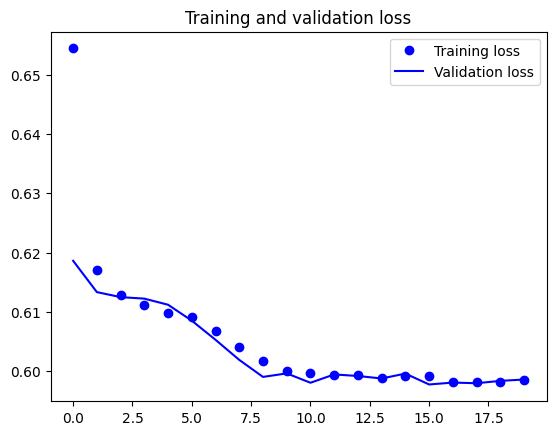

In [ ]:
# Loss and PLOT
loss = autoencoder.history.history['loss']
val_loss = autoencoder.history.history['val_loss']
epochs = range(20)
plt.figure()
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.savefig("train_test_loss.jpeg")


The code involves compiling and training an autoencoder model using the Adam optimizer and binary cross-entropy loss. It compiles the model with specified optimizer and loss, trains it using training data, and creates an encoder model to extract the compressed representation. An input layer for the encoded data is also defined.

## **10. Prediction**

In [ ]:
# Prediction
encoded_train = pd.DataFrame(encoder.predict(train))
encoded_train = encoded_train.add_prefix('feature_')
encoded_test = pd.DataFrame(encoder.predict(test))
encoded_test = encoded_test.add_prefix('feature_')

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


These lines predict encoded features using the encoder model:

For training data (train), the encoded representations are stored in 'encoded_train' DataFrame with column names prefixed by 'feature_'.
Similarly, encoded representations of test data (test) are saved in 'encoded_test' DataFrame with prefixed column names.
In essence, these lines generate encoded representations for training and test data via the encoder model, stored in DataFrames. These encoded features hold potential for further analysis or as input to other models.

## **11. Print output**

In [ ]:
print (encoded_train.shape)
print (encoded_test.shape)

(293, 50)
(74, 50)


The code lines "print(encoded_train.shape)" and "print(encoded_test.shape)" will display the shape of the encoded training and test data, respectively. The output shapes represent the number of samples (rows) and encoded dimensions (columns) generated by the encoder model for both datasets. This helps understand the dimensions of the encoded representations.

## **12. Combine IDs with encoded output matrix**

In [ ]:
train_out=pd.concat([train_id,encoded_train], axis=1)
test_out=pd.concat([test_id,encoded_test], axis=1)


The code combines 'train_id' with 'encoded_train' horizontally, forming 'train_out', and similarly combines 'test_id' with 'encoded_test' to create 'test_out'. In 'train_out', 'train_id' serves as identifiers, followed by encoded features from 'encoded_train'. Likewise, 'test_out' merges 'test_id' identifiers with 'encoded_test' features, producing new DataFrames that associate samples with their encoded representations.

## **13. Write into output files**

In [ ]:
# OUTPUT FEATURE EXTRACTED DATASET
train_out.to_csv('deep_train_mat.csv', index=False)
test_out.to_csv('deep_test_mat.csv', index=False)

The code "train_out.to_csv('deep_train_mat.csv', index=False)" saves 'train_out' DataFrame to "deep_train_mat.csv", excluding the row index. Similarly, "test_out.to_csv('deep_test_mat.csv', index=False)" saves 'test_out' to "deep_test_mat.csv". This approach facilitates data storage and sharing for subsequent analysis or modeling.


# **Practice Codes: Try it yourself**

### **Assignment 1:**
In this assignment, you will build upon your knowledge of Dimensionality reduction with Deep learning. The provided code is incomplete, with missing syntax and portions. Your task is to complete the code to successfully perform Dimensionality reduction with Deep learning. To complete this, use the following txt file:
**Training data**- https://raw.githubusercontent.com/pine-bio-support/Predictive_model_Classification_Regression/main/train_data.txt
**Test data**- https://raw.githubusercontent.com/pine-bio-support/Predictive_model_Classification_Regression/main/test_data.txt

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

Load Data Training and Test Data

In [ ]:
train = pd.read_csv("/train_data.txt", sep='\t')
test = pd.read_csv("/test_data.txt", sep='\t')

FileNotFoundError: ignored

Extract Training and Test Ids

In [ ]:
#Extract train ids
train_id = train['id']
train_id=train_id.reset_index(drop=)

#Extract test ids
test_id = test['id']
test_id=test_id.reset_index(drop=)

5 fold Cross-validation on training data

In [ ]:
# split if training data into 5 folds
Xtrain,Xvalidation=train_test_split(train,train_size=0.8,random_state=42)

In [ ]:
#Drop id column from training and test data
train.drop(['id'], axis=1,inplace=True)
Xtrain.drop(['id'], axis=1,inplace=True)
Xvalidation.drop(['id'], axis=1,inplace=True)
test.drop(['id'], axis=1,inplace=True)

Dimensionality Reduction with Autoencoder

In [ ]:
from keras.layers import Dense,Input,Dropout
from keras.models import Model
from matplotlib import pyplot as plt
from sklearn.neural_network import MLPClassifier as ANN

# USING FUNCTIONAL API MODEL
ncol = train.shape[1]
input_dim = Input(shape = (ncol, ))
encoding_dim = 50
encoded = Dense(500, activation = )(input_dim)
encoded = Dropout(0.5)(encoded) #DROUPOUT
encoded = Dense(100, activation = )(encoded)
encoded = Dense(, activation = 'relu')(encoded)     # BOTTLENECK LAYER

Add Decoder layer

In [ ]:
# Decoder Layers
decoded = Dense(100, activation = 'relu')(encoded)
decoded = Dense(500, activation = 'relu')(decoded)
decoded = Dense(ncol, activation = 'sigmoid')(decoded)

Combine encoder and Decoder layers

In [ ]:
# Compile the Model
autoencoder.(optimizer = 'Adam', loss = 'binary_crossentropy')

#Fit model training data
autoencoder.(train, train, epochs = 20,verbose=1, batch_size = 32, shuffle = False, validation_data = (Xvalidation, Xvalidation))

encoder = Model(inputs = input_dim, outputs = encoded) #ASSIGN BOTTLENECK LAYER DATA AS OUTPUT
encoded_input = Input(shape = (encoding_dim, ))

In [ ]:
# Loss and PLOT
loss = autoencoder.history.history['loss']
val_loss = autoencoder.history.history['val_loss']
epochs = range(20)
plt.figure()
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.savefig("train_test_loss.jpeg")

Prediction on training and test data

In [ ]:
# Prediction
encoded_train = pd.DataFrame(encoder.(train))
encoded_train = encoded_train.add_prefix('feature_')
encoded_test = pd.DataFrame(encoder.predict(test))
encoded_test = encoded_test.add_prefix('feature_')

In [ ]:
train_out=pd.concat([train_id,encoded_train], axis=1)
test_out=pd.concat([test_id,encoded_test], axis=1)

In [ ]:
# Write output of extarcted features into a CSV dile
train_out.('deep_train_mat.csv', index=False)
test_out.('deep_test_mat.csv', index=False)